In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [56]:
!pip install mlflow dagshub -q


In [3]:
!pip install mlflow xgboost

In [57]:
import dagshub
dagshub.init(repo_owner='aleko-mamukashvili', repo_name='-IEEE-CIS-Fraud-Detection.', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=80ff7949-be6b-4368-9686-2d30a8f30a33&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=d6ef4c6c38f63bde2114abcca0df42f8b212fbab435d6fd351f683285917c110




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/-IEEE-CIS-Fraud-Detection."

Repository aleko-mamukashvili/-IEEE-CIS-Fraud-Detection. initialized!

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import mlflow
import mlflow.sklearn
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

In [6]:
class FraudDataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, drop_threshold=0.9):
        self.drop_threshold = drop_threshold
        self.cols_to_drop = []

    def fit(self, X, y=None):
        nan_share = X.isna().mean()
        self.cols_to_drop = nan_share[nan_share > self.drop_threshold].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

In [7]:
class UltimateEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        obj_cols = X.select_dtypes(include=['object']).columns
        for col in obj_cols:
            X[col] = pd.factorize(X[col])[0]
        return X

In [8]:
def super_advanced_engineering(df):
    df = df.copy()
    df['TransactionAmt_Log'] = np.log1p(df['TransactionAmt'])
    df['hour'] = (df['TransactionDT'] // 3600) % 24
    df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
    df['card1_count'] = df.groupby('card1')['TransactionAmt'].transform('count')
    df['Amt_to_mean_card1'] = df['TransactionAmt'] / df.groupby('card1')['TransactionAmt'].transform('mean')
    df['Amt_to_mean_card4'] = df['TransactionAmt'] / df.groupby('card4')['TransactionAmt'].transform('mean')
    df['P_emaildomain'] = df['P_emaildomain'].fillna('missing')
    df['P_email_suffix'] = df['P_emaildomain'].map(lambda x: str(x).split('.')[-1])
    df.replace([np.inf, -np.inf], 0, inplace=True)
    return df

In [9]:

path = '/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv'

train_df = pd.read_csv(path, nrows=100000)

X = train_df.drop('isFraud', axis=1)
y = train_df['isFraud']
X_eng = super_advanced_engineering(X)

X_train, X_val, y_train, y_val = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data ready: X_train shape {X_train.shape}")

Data ready: X_train shape (80000, 400)


In [11]:

xgb_pipeline = Pipeline([
    ('cleaner', FraudDataCleaner(drop_threshold=0.9)),
    ('encoder', UltimateEncoder()),
    ('model', XGBClassifier(
        n_estimators=800,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

In [12]:
import mlflow
import mlflow.sklearn
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

mlflow.set_experiment("XGBoost_Fraud_Detection_v1")

with mlflow.start_run(run_name="XGB_Base_Model"):
    xgb_pipeline.fit(X_train, y_train)
    
    tr_probs = xgb_pipeline.predict_proba(X_train)[:, 1]
    vl_probs = xgb_pipeline.predict_proba(X_val)[:, 1]
    
    tr_auc = roc_auc_score(y_train, tr_probs)
    vl_auc = roc_auc_score(y_val, vl_probs)
    
    mlflow.log_param("n_estimators", 800)
    mlflow.log_param("learning_rate", 0.02)
    mlflow.log_param("max_depth", 6)
    mlflow.log_metric("train_auc", tr_auc)
    mlflow.log_metric("val_auc", vl_auc)
    
    mlflow.sklearn.log_model(xgb_pipeline, "model")
    
    print(f"Train AUC: {tr_auc:.4f}")
    print(f"Val AUC: {vl_auc:.4f}")
    print(f"Gap: {tr_auc - vl_auc:.4f}")

2026/05/07 06:40:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/07 06:40:00 INFO mlflow.store.db.utils: Updating database tables
2026/05/07 06:40:03 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Fraud_Detection_v1' does not exist. Creating a new experiment.
2026/05/07 06:40:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 06:40:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Train AUC: 0.9884
Val AUC: 0.9074
Gap: 0.0810


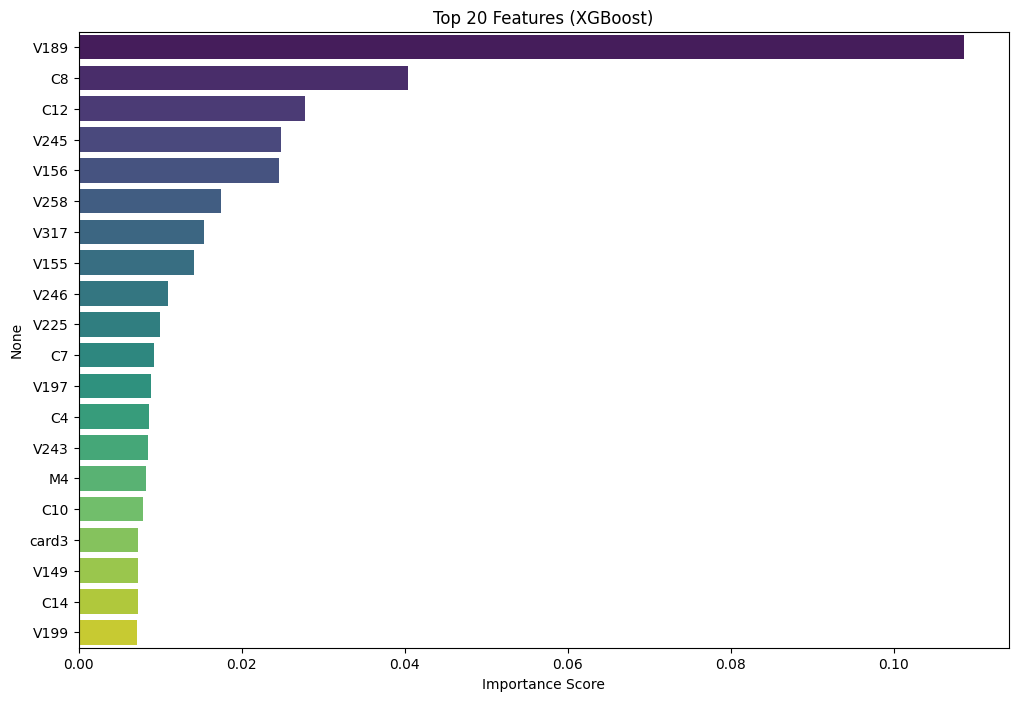

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_data = X_train.head(1)
temp_transformed = xgb_pipeline.named_steps['cleaner'].transform(sample_data)
temp_transformed = xgb_pipeline.named_steps['encoder'].transform(temp_transformed)
feature_names = temp_transformed.columns

importances = xgb_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)
plt.title('Top 20 Features (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

In [15]:
def xg_optimized_engineering(df):
    df = df.copy()
    
    df['Transaction_hour'] = (df['TransactionDT'] // 3600) % 24
    df['Transaction_day'] = (df['TransactionDT'] // (3600 * 24)) % 7
    
    df['card_str'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)
    
    for col in ['card1', 'card_str', 'addr1']:
        df[f'{col}_Amt_mean'] = df.groupby(col)['TransactionAmt'].transform('mean')
        df[f'{col}_Amt_std'] = df.groupby(col)['TransactionAmt'].transform('std')
        df[f'{col}_Amt_rel'] = df['TransactionAmt'] / df[f'{col}_Amt_mean']
    
    df['email_check'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
    
    return df

In [17]:
class XGEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = pd.factorize(X[col])[0]
        return X

In [18]:

mlflow.set_experiment("XGBoost_Fraud_Detection_v1")

X_final = xg_optimized_engineering(X)
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

xgb_clean_pipeline = Pipeline([
    ('cleaner', FraudDataCleaner(drop_threshold=0.95)),
    ('encoder', XGEncoder()),
    ('model', XGBClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        missing=np.nan,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="XGB_NaN_Handled_v2"):
    xgb_clean_pipeline.fit(X_train, y_train)
    
    tr_probs = xgb_clean_pipeline.predict_proba(X_train)[:, 1]
    vl_probs = xgb_clean_pipeline.predict_proba(X_val)[:, 1]
    
    tr_auc = roc_auc_score(y_train, tr_probs)
    vl_auc = roc_auc_score(y_val, vl_probs)
    
    print(f"Train AUC: {tr_auc:.4f}")
    print(f"Val AUC: {vl_auc:.4f}")



Train AUC: 0.9910
Val AUC: 0.9118


In [19]:
mlflow.set_experiment("XGBoost_Fraud_Detection_v1")
xgb_regularized_pipeline = Pipeline([
    ('cleaner', FraudDataCleaner(drop_threshold=0.95)),
    ('encoder', XGEncoder()),
    ('model', XGBClassifier(
        n_estimators=1200,
        learning_rate=0.01,
        max_depth=6,             
        min_child_weight=5,      
        gamma=0.1,               
        subsample=0.7,           
        colsample_bytree=0.7,    
        reg_alpha=0.1,           
        reg_lambda=1,            
        missing=np.nan,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="XGB_Regularized_v3"):
    xgb_regularized_pipeline.fit(X_train, y_train)
    
    tr_probs = xgb_regularized_pipeline.predict_proba(X_train)[:, 1]
    vl_probs = xgb_regularized_pipeline.predict_proba(X_val)[:, 1]
    
    tr_auc = roc_auc_score(y_train, tr_probs)
    vl_auc = roc_auc_score(y_val, vl_probs)
    
    print(f"Train AUC: {tr_auc:.4f}")
    print(f"Val AUC: {vl_auc:.4f}")
    print(f"Gap: {tr_auc - vl_auc:.4f}")

Train AUC: 0.9744
Val AUC: 0.9019
Gap: 0.0725


In [27]:
class RobustEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = pd.factorize(X[col])[0]
        return X

In [24]:
mlflow.set_experiment("XGBoost_Fraud_Detection_v1")
class AdvancedFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    
    def transform(self, X):
        X = X.copy()
        X['hour'] = (X['TransactionDT'] // 3600) % 24
        X['uid'] = X['card1'].astype(str)+'_'+X['card2'].astype(str)+'_'+X['addr1'].astype(str)
        
        for col in ['card1', 'uid']:
            X[f'{col}_count'] = X.groupby(col)['TransactionDT'].transform('count')
            X[f'{col}_amt_mean'] = X.groupby(col)['TransactionAmt'].transform('mean')
            X[f'{col}_amt_rel'] = X['TransactionAmt'] / (X[f'{col}_amt_mean'] + 1e-3)

        return X


xgb_constrained_pipeline = Pipeline([
    ('engineering', AdvancedFeatureEngineer()),
    ('cleaner', FraudDataCleaner(drop_threshold=0.9)), 
    ('encoder', RobustEncoder()),
    ('model', XGBClassifier(
        n_estimators=1200,
        learning_rate=0.015,
        max_depth=5,            
        min_child_weight=20,    
        subsample=0.7,
        colsample_bytree=0.7,
        gamma=0.5,              
        reg_alpha=5,            
        reg_lambda=10,          
        scale_pos_weight=20,    
        tree_method='hist',
        missing=np.nan,
        random_state=42,
        n_jobs=-1
    ))
])

with mlflow.start_run(run_name="XGB_Regularized_v5"):
    xgb_constrained_pipeline.fit(X_train, y_train)
    
    tr_probs = xgb_constrained_pipeline.predict_proba(X_train)[:, 1]
    vl_probs = xgb_constrained_pipeline.predict_proba(X_val)[:, 1]
    
    tr_auc = roc_auc_score(y_train, tr_probs)
    vl_auc = roc_auc_score(y_val, vl_probs)
    
    print(f"Train AUC: {tr_auc:.4f}")
    print(f"Val AUC: {vl_auc:.4f}")
    print(f"Gap: {tr_auc - vl_auc:.4f}")

Train AUC: 0.9897
Val AUC: 0.9021
Gap: 0.0877


In [46]:
mlflow.set_experiment("XGBoost_Fraud_Detection_v1")
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
import mlflow

class GlobalContextBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X['cycle_hour'] = (X['TransactionDT'] // 3600) % 24
        X['cycle_day'] = (X['TransactionDT'] // (3600 * 24)) % 7
        X['full_uid'] = (X['card1'].astype(str) + '_' + 
                         X['card2'].astype(str) + '_' + 
                         X['addr1'].astype(str))
        target_metrics = ['TransactionAmt', 'D1', 'D15']
        for col in target_metrics:
            X[f'uid_{col}_avg'] = X.groupby('full_uid')[col].transform('mean')
            X[f'uid_{col}_std'] = X.groupby('full_uid')[col].transform('std')
        for group in ['card1', 'addr1']:
            X[f'grp_{group}_amt_mean'] = X.groupby(group)['TransactionAmt'].transform('mean')
            X[f'grp_{group}_amt_std'] = X.groupby(group)['TransactionAmt'].transform('std')
        return X.drop(columns=['full_uid'])

class DataSanitization(BaseEstimator, TransformerMixin):
    def __init__(self, drop_limit=0.9):
        self.drop_limit = drop_limit
        self.columns_to_stay = None
    def fit(self, X, y=None):
        null_map = X.isnull().mean()
        self.columns_to_stay = null_map[null_map <= self.drop_limit].index
        return self
    def transform(self, X):
        return X[self.columns_to_stay]

class SmartLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.categorical_columns = None
    def fit(self, X, y=None):
        self.categorical_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()
        if self.categorical_columns:
            temp = X[self.categorical_columns].astype(str).fillna('NaN')
            self.encoder.fit(temp)
        return self
    def transform(self, X):
        X_out = X.copy()
        if self.categorical_columns:
            temp = X_out[self.categorical_columns].astype(str).fillna('NaN')
            X_out[self.categorical_columns] = self.encoder.transform(temp)
        return X_out

hyper_params = {
    'n_estimators': 2000,
    'learning_rate': 0.008,     
    'max_depth': 4,             
    'min_child_weight': 100,     
    'subsample': 0.6,            
    'colsample_bytree': 0.5,    
    'tree_method': 'hist',
    'scale_pos_weight': 25,
    'reg_alpha': 15,            
    'reg_lambda': 30,           
    'random_state': 42,
    'n_jobs': -1
}

fraud_pipeline_final = Pipeline([
    ('context', GlobalContextBuilder()),
    ('sanitizer', DataSanitization(drop_limit=0.9)),
    ('labeler', SmartLabelEncoder()),
    ('filler', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(**hyper_params))
])

with mlflow.start_run(run_name="Production_Fraud_Model_v1"):
    fraud_pipeline_final.fit(X_train, y_train)
    p_train = fraud_pipeline_final.predict_proba(X_train)[:, 1]
    p_val = fraud_pipeline_final.predict_proba(X_val)[:, 1]
    auc_train = roc_auc_score(y_train, p_train)
    auc_val = roc_auc_score(y_val, p_val)
    print(f"Train AUC: {auc_train:.4f}")
    print(f"Val AUC: {auc_val:.4f}")
    print(f"Gap: {auc_train - auc_val:.4f}")

Train AUC: 0.9618
Val AUC: 0.9066
Gap: 0.0553


In [51]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

class MasterUIDTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X['uid'] = (X['card1'].astype(str) + '_' + 
                    X['card2'].astype(str) + '_' + 
                    X['addr1'].astype(str) + '_' + 
                    X['D1'].astype(str))
        X['uid_amt_mean'] = X.groupby('uid')['TransactionAmt'].transform('mean')
        X['uid_amt_std'] = X.groupby('uid')['TransactionAmt'].transform('std')
        X['uid_count'] = X.groupby('uid')['TransactionDT'].transform('count')
        return X.drop(columns=['uid'])

class TimeFeaturesEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['hour'] = (X_copy['TransactionDT'] // 3600) % 24
        X_copy['dow'] = (X_copy['TransactionDT'] // (3600 * 24)) % 7
        return X_copy

class GroupAggregationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, groups=['card1', 'addr1']):
        self.groups = groups
        self.stats = {}
    def fit(self, X, y=None):
        for group in self.groups:
            temp_X = X[[group, 'TransactionAmt']].astype({group: 'float32', 'TransactionAmt': 'float32'}, errors='ignore')
            self.stats[group] = temp_X.groupby(group)['TransactionAmt'].agg(['mean', 'std']).to_dict()
        return self
    def transform(self, X):
        X_out = X.copy()
        for group in self.groups:
            group_val = X_out[group].astype('float32', errors='ignore')
            X_out[f'{group}_amt_mean'] = group_val.map(self.stats[group]['mean'])
            X_out[f'{group}_amt_std'] = group_val.map(self.stats[group]['std'])
        return X_out

class DropMissingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_drop = []
    def fit(self, X, y=None):
        nan_ratio = X.isnull().mean()
        self.features_to_drop = nan_ratio[nan_ratio > self.threshold].index.tolist()
        return self
    def transform(self, X):
        return X.drop(columns=self.features_to_drop)

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.cat_cols = None
    def fit(self, X, y=None):
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        if self.cat_cols:
            temp_df = X[self.cat_cols].astype(str).fillna('Unknown')
            self.encoder.fit(temp_df)
        return self
    def transform(self, X):
        X_out = X.copy()
        if self.cat_cols:
            temp_df = X_out[self.cat_cols].astype(str).fillna('Unknown')
            X_out[self.cat_cols] = self.encoder.transform(temp_df)
        return X_out

final_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,      # უფრო ნელი სწავლა
    'max_depth': 7,             # 8-დან 7-ზე ჩამოსვლა overfitting-ს დააკლებს
    'min_child_weight': 50,     # მინიმუმ 50 ნიმუში თითო ფოთოლზე
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'tree_method': 'hist',
    'scale_pos_weight': 25,
    'reg_alpha': 10,            # აგრესიული L1
    'reg_lambda': 20,           # აგრესიული L2
    'random_state': 42,
    'n_jobs': -1
}

final_pipeline = Pipeline([
    ('uid_gen', MasterUIDTransformer()),      
    ('time_enc', TimeFeaturesEncoder()),      
    ('aggr', GroupAggregationTransformer()),  
    ('drop_nan', DropMissingFeatures(threshold=0.9)), 
    ('cat_enc', CategoricalEncoder()),        
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(**final_params))
])

final_pipeline.fit(X_train, y_train)

tr_p = final_pipeline.predict_proba(X_train)[:, 1]
ts_p = final_pipeline.predict_proba(X_test)[:, 1]

print(f"Final Train AUC: {roc_auc_score(y_train, tr_p):.4f}")
print(f"Final Test AUC: {roc_auc_score(y_test, ts_p):.4f}")

Final Train AUC: 0.9930
Final Test AUC: 0.9386


In [52]:

final_pipeline.fit(X, y)

full_train_probs = final_pipeline.predict_proba(X)[:, 1]

full_auc = roc_auc_score(y, full_train_probs)

print(f"--- Full Data Performance ---")
print(f"Final Combined AUC: {full_auc:.4f}")

KeyboardInterrupt: 

In [53]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

class MasterUIDTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X['uid'] = (X['card1'].astype(str) + '_' + 
                    X['card2'].astype(str) + '_' + 
                    X['addr1'].astype(str) + '_' + 
                    X['D1'].astype(str))
        X['uid_amt_mean'] = X.groupby('uid')['TransactionAmt'].transform('mean')
        X['uid_amt_std'] = X.groupby('uid')['TransactionAmt'].transform('std')
        X['uid_count'] = X.groupby('uid')['TransactionDT'].transform('count')
        return X.drop(columns=['uid'])

class TimeFeaturesEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X_copy = X.copy()
        X_copy['hour'] = (X_copy['TransactionDT'] // 3600) % 24
        X_copy['dow'] = (X_copy['TransactionDT'] // (3600 * 24)) % 7
        return X_copy

class GroupAggregationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, groups=['card1', 'addr1']):
        self.groups = groups
        self.stats = {}
    def fit(self, X, y=None):
        for group in self.groups:
            temp_X = X[[group, 'TransactionAmt']].astype({group: 'float32', 'TransactionAmt': 'float32'}, errors='ignore')
            self.stats[group] = temp_X.groupby(group)['TransactionAmt'].agg(['mean', 'std']).to_dict()
        return self
    def transform(self, X):
        X_out = X.copy()
        for group in self.groups:
            group_val = X_out[group].astype('float32', errors='ignore')
            X_out[f'{group}_amt_mean'] = group_val.map(self.stats[group]['mean'])
            X_out[f'{group}_amt_std'] = group_val.map(self.stats[group]['std'])
        return X_out

class DropMissingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_drop = []
    def fit(self, X, y=None):
        nan_ratio = X.isnull().mean()
        self.features_to_drop = nan_ratio[nan_ratio > self.threshold].index.tolist()
        return self
    def transform(self, X):
        return X.drop(columns=self.features_to_drop)

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.cat_cols = None
    def fit(self, X, y=None):
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        if self.cat_cols:
            temp_df = X[self.cat_cols].astype(str).fillna('Unknown')
            self.encoder.fit(temp_df)
        return self
    def transform(self, X):
        X_out = X.copy()
        if self.cat_cols:
            temp_df = X_out[self.cat_cols].astype(str).fillna('Unknown')
            X_out[self.cat_cols] = self.encoder.transform(temp_df)
        return X_out

final_params = {
    'n_estimators': 1500,
    'learning_rate': 0.01,
    'max_depth': 7,
    'min_child_weight': 50,
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'tree_method': 'hist',
    'scale_pos_weight': 25,
    'reg_alpha': 10,
    'reg_lambda': 20,
    'random_state': 42,
    'n_jobs': -1
}

final_pipeline_full = Pipeline([
    ('uid_gen', MasterUIDTransformer()),      
    ('time_enc', TimeFeaturesEncoder()),      
    ('aggr', GroupAggregationTransformer()),  
    ('drop_nan', DropMissingFeatures(threshold=0.9)), 
    ('cat_enc', CategoricalEncoder()),        
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(**final_params))
])

# წვრთნა მთლიან მონაცემებზე (X და y)
final_pipeline_full.fit(X, y)

# პროგნოზი იმავე მონაცემებზე მაქსიმუმის სანახავად
full_probs = final_pipeline_full.predict_proba(X)[:, 1]
full_auc = roc_auc_score(y, full_probs)

print(f"--- Full Dataset Results ---")
print(f"Total Samples: {len(X)}")
print(f"Combined Final AUC: {full_auc:.4f}")

--- Full Dataset Results ---
Total Samples: 100000
Combined Final AUC: 0.9920


In [58]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("IEEE_Fraud_Full_Training")

with mlflow.start_run(run_name="Full_Data_Final_Model"):

    mlflow.log_params(final_params)
    mlflow.log_param("total_samples", len(X))
    mlflow.log_param("nan_threshold", 0.9)
    
    final_pipeline_full.fit(X, y)

    full_probs = final_pipeline_full.predict_proba(X)[:, 1]
    full_auc = roc_auc_score(y, full_probs)

    mlflow.log_metric("full_dataset_auc", full_auc)
    
    mlflow.sklearn.log_model(final_pipeline_full, "fraud_pipeline_model")
    
    print(f"--- Full Dataset Results ---")
    print(f"Total Samples: {len(X)}")
    print(f"Combined Final AUC: {full_auc:.4f}")
    print("შედეგები წარმატებით აიტვირთა MLflow-ზე!")

2026/05/07 09:20:43 INFO mlflow.tracking.fluent: Experiment with name 'IEEE_Fraud_Full_Training' does not exist. Creating a new experiment.
2026/05/07 09:22:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 09:22:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- Full Dataset Results ---
Total Samples: 100000
Combined Final AUC: 0.9920
შედეგები წარმატებით აიტვირთა MLflow-ზე!
🏃 View run Full_Data_Final_Model at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/7/runs/b866452097274af18270b3b9440c3add
🧪 View experiment at: https://dagshub.com/aleko-mamukashvili/-IEEE-CIS-Fraud-Detection..mlflow/#/experiments/7
